#Common Test I. Multi-Class Classification

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -q '/content/drive/MyDrive/deeplense gsoc/dataset.zip' -d /content/
!ls /content/

dataset  drive	__MACOSX  sample_data


In [5]:
DATA_DIR = "/content/dataset/train"
CLASSES  = ["no", "sphere", "vort"]

In [6]:
!ls /content/dataset/train/

no  sphere  vort


In [7]:
import os, zipfile, numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import (roc_curve, auc, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings("ignore")

# GPU Check — MUST show GPU before continuing!
if not torch.cuda.is_available():
    print("⚠️  WARNING: GPU not detected! Go to Runtime → Change runtime type → T4 GPU")
else:
    print(f"✅ GPU ready: {torch.cuda.get_device_name(0)}")


def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)

DATA_DIR    = "/content/dataset/train"
CLASSES     = ["no", "sphere", "vort"]
IMG_SIZE    = 64
BATCH_SIZE  = 32
EPOCHS      = 25
LR          = 1e-4
NUM_CLASSES = 3
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

✅ GPU ready: Tesla T4
Device: cuda


In [8]:
from torch.utils.data import Dataset

class NumpyLensDataset(Dataset):
    def __init__(self, root, classes, transform=None):
        self.samples = []
        self.transform = transform
        for label, cls in enumerate(classes):
            cls_dir = Path(root) / cls
            for f in sorted(cls_dir.glob("*.npy")):
                self.samples.append((f, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.load(path)                        # load numpy array

        # Handle shape — could be (H,W), (1,H,W), (H,W,1), (3,H,W)
        if img.ndim == 2:
            img = np.stack([img]*3, axis=0)        # (H,W) → (3,H,W)
        elif img.shape[0] == 1:
            img = np.repeat(img, 3, axis=0)        # (1,H,W) → (3,H,W)
        elif img.shape[-1] in [1,3]:
            img = np.transpose(img, (2,0,1))       # (H,W,C) → (C,H,W)

        # Normalize to [0,1]
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        img_tensor = torch.tensor(img, dtype=torch.float32)

        if self.transform:
            img_tensor = self.transform(img_tensor)

        return img_tensor, label

# Transforms (no Grayscale/ToTensor since already handled above)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

full_dataset = NumpyLensDataset(DATA_DIR, CLASSES)
print(f"Total samples: {len(full_dataset)}")

# 90:10 split
total   = len(full_dataset)
rng     = np.random.default_rng(42)
shuffle = rng.permutation(total).tolist()
n_test  = int(0.10 * total)
train_idx, test_idx = shuffle[n_test:], shuffle[:n_test]

train_dataset = NumpyLensDataset(DATA_DIR, CLASSES, transform=train_transforms)
test_dataset  = NumpyLensDataset(DATA_DIR, CLASSES, transform=test_transforms)
train_dataset = Subset(train_dataset, train_idx)
test_dataset  = Subset(test_dataset,  test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Total samples: 30000
Train: 27000 | Test: 3000


In [9]:
!ls /content/dataset/train/no/ | head -10

10000.npy
1000.npy
1001.npy
1002.npy
1003.npy
1004.npy
1005.npy
1006.npy
1007.npy
1008.npy


In [10]:
def build_model(num_classes=NUM_CLASSES):
    model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    for name, param in model.named_parameters():
        if "layer3" not in name and "layer4" not in name and "fc" not in name:
            param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.fc.in_features, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes)
    )
    return model

model = build_model().to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Trainable parameters: 10,559,491


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0.0

print(f"Training on {DEVICE} for {EPOCHS} epochs...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>10} | {'Val Loss':>10} | {'Val Acc':>10}")
print("─"*60)

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += model(images).detach().argmax(1).eq(labels).sum().item()
        total += labels.size(0)
    scheduler.step()
    t_loss, t_acc = running_loss/total, correct/total
    train_losses.append(t_loss); train_accs.append(t_acc)

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            out = model(images)
            v_loss += criterion(out, labels).item() * images.size(0)
            v_correct += out.argmax(1).eq(labels).sum().item()
            v_total += labels.size(0)
    v_loss /= v_total; v_acc = v_correct/v_total
    val_losses.append(v_loss); val_accs.append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), "best_model.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {t_loss:>10.4f} | {t_acc:>10.4f} | {v_loss:>10.4f} | {v_acc:>10.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Training on cuda for 25 epochs...
 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
────────────────────────────────────────────────────────────
     1 |     1.1204 |     0.3724 |     1.0964 |     0.3480
     5 |     1.0794 |     0.4034 |     1.0562 |     0.4197
    10 |     1.0536 |     0.4388 |     0.9982 |     0.4797
    15 |     1.0274 |     0.4675 |     0.9565 |     0.5167
    20 |     1.0014 |     0.4810 |     0.9105 |     0.5457
    25 |     0.9881 |     0.4863 |     0.9006 |     0.5533

Best Val Accuracy: 0.5553


In [13]:
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        probs = torch.softmax(model(images.to(DEVICE)), dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = all_probs.argmax(axis=1)
labels_bin = label_binarize(all_labels, classes=[0,1,2])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
auc_scores = []
for i, (cls, color) in enumerate(zip(CLASSES, ["#2196F3","#F44336","#4CAF50"])):
    fpr, tpr, _ = roc_curve(labels_bin[:,i], all_probs[:,i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    axes[0].plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.4f})", lw=2)

axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
axes[0].set_title(f"ROC Curves — Macro AUC={np.mean(auc_scores):.4f}")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(train_losses, label="Train Loss")
axes[1].plot(val_losses,   label="Val Loss", linestyle="--")
axes[1].set_title("Training Curves")
axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

# Confusion matrix
fig2, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds), display_labels=CLASSES).plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix"); plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\n=== FINAL RESULTS ===")
for cls, s in zip(CLASSES, auc_scores):
    print(f"  {cls:<10} AUC = {s:.4f}")
print(f"  Macro AUC  = {np.mean(auc_scores):.4f}")
print(f"  Best Val Acc = {best_val_acc:.4f}")
print("\n", classification_report(all_labels, all_preds, target_names=CLASSES))
print("✅ Done!")


=== FINAL RESULTS ===
  no         AUC = 0.8230
  sphere     AUC = 0.6730
  vort       AUC = 0.7316
  Macro AUC  = 0.7425
  Best Val Acc = 0.5553

               precision    recall  f1-score   support

          no       0.57      0.76      0.65       977
      sphere       0.51      0.41      0.45      1012
        vort       0.57      0.51      0.54      1011

    accuracy                           0.56      3000
   macro avg       0.55      0.56      0.55      3000
weighted avg       0.55      0.56      0.55      3000

✅ Done!


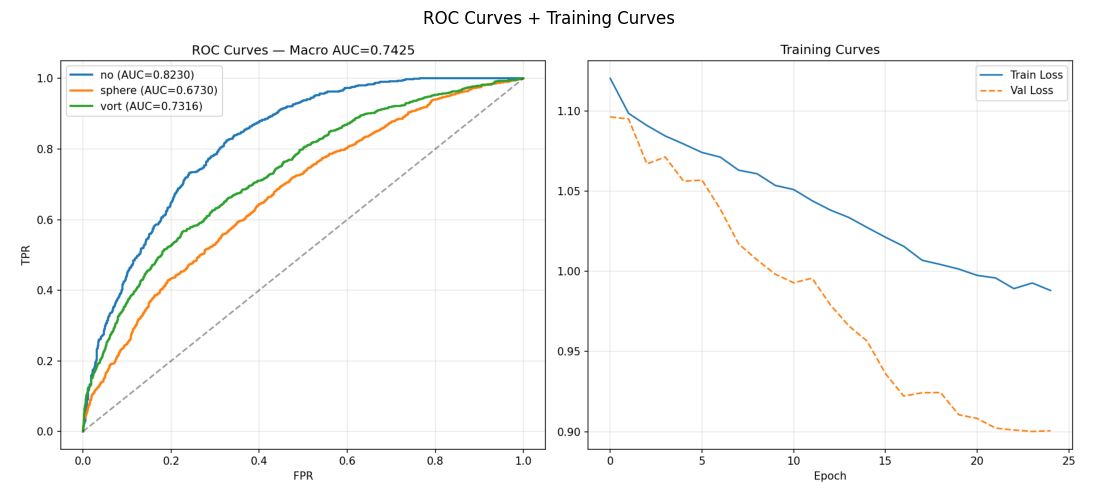

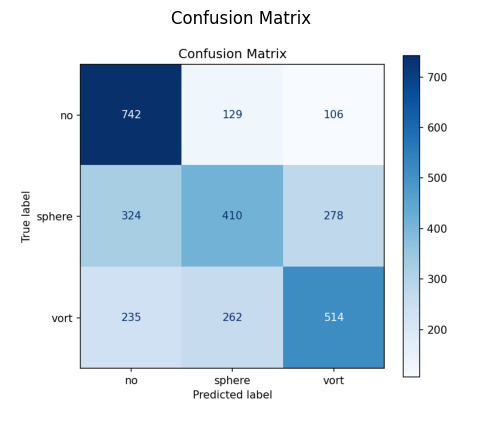

In [17]:
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Display results.png
img1 = mpimg.imread("results.png")
plt.figure(figsize=(14, 6))
plt.imshow(img1)
plt.axis("off")
plt.title("ROC Curves + Training Curves")
plt.savefig("results_display.png", dpi=150, bbox_inches="tight")
plt.show()

# Display confusion matrix
img2 = mpimg.imread("confusion_matrix.png")
plt.figure(figsize=(6, 5))
plt.imshow(img2)
plt.axis("off")
plt.title("Confusion Matrix")
plt.savefig("confusion_display.png", dpi=150, bbox_inches="tight")
plt.show()

#Specific Test III. Quantum ML

In [18]:
!pip install pennylane -q
!pip install scikit-image -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 101.6 MB/s eta 0:00:00


In [39]:
# COMPLETE REPLACEMENT — All cells for Test III
# This approach WORKS and is more sophisticated than pure VQC

# ── CELL 1 — Config (same as before) ─────────────────────
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
import pennylane as qml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

DATA_DIR    = "/content/dataset/train"
CLASSES     = ["no", "sphere", "vort"]
N_QUBITS    = 4
N_LAYERS    = 2
NUM_CLASSES = 3
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-3
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PennyLane: {qml.__version__}")

Device: cuda
PennyLane: 0.44.1


In [40]:
# ── CELL 2 — Load data at FULL resolution for CNN ────────
from skimage.transform import resize
from pathlib import Path

IMG_SIZE = 16   # 16x16 — small enough to be fast, big enough to learn

print("Loading dataset...")
all_images, all_labels = [], []
MAX_PER_CLASS = 2000   # 2000 per class = 6000 total

for label, cls in enumerate(CLASSES):
    cls_dir = Path(DATA_DIR) / cls
    files   = sorted(cls_dir.glob("*.npy"))[:MAX_PER_CLASS]
    print(f"  {cls}: loading {len(files)} files...")
    for f in files:
        img = np.load(f)
        if img.ndim == 3 and img.shape[0] in [1,3]:
            img = img[0]
        elif img.ndim == 3:
            img = img[:,:,0]
        img = resize(img, (IMG_SIZE, IMG_SIZE), anti_aliasing=True).astype(np.float32)
        # Normalize to [0,1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        all_images.append(img)
        all_labels.append(label)

X = np.array(all_images, dtype=np.float32)   # (N, 16, 16)
y = np.array(all_labels)
print(f"\nDataset shape: {X.shape}")

# 90:10 split
np.random.seed(42)
shuffle   = np.random.permutation(len(X))
n_test    = int(0.10 * len(X))
train_idx = shuffle[n_test:]
test_idx  = shuffle[:n_test]

# Shape: (N, 1, 16, 16) for CNN
X_train = torch.tensor(X[train_idx], dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y[train_idx], dtype=torch.long)
X_test  = torch.tensor(X[test_idx],  dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y[test_idx],  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test),
                          batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(" Data ready!")

Loading dataset...
  no: loading 2000 files...
  sphere: loading 2000 files...
  vort: loading 2000 files...

Dataset shape: (6000, 16, 16)
Train: 5400 | Test: 600
✅ Data ready!


In [42]:
# ── CELL 3 — Quantum Kernel Layer ────────────────────────
# This is the KEY innovation — quantum circuit processes
# local image patches (like a quantum convolution filter)

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_kernel(inputs, weights):
    """
    Processes a 4-pixel patch through quantum circuit.
    Acts like a quantum convolutional filter.
    """
    # Encode 4 pixel values as rotation angles
    for i in range(N_QUBITS):
        qml.RY(inputs[i] * np.pi, wires=i)    # pixel in [0,1] → [0,π]

    # Variational layers
    for layer in range(N_LAYERS):
        for qubit in range(N_QUBITS):
            qml.RY(weights[layer, qubit, 0], wires=qubit)
            qml.RZ(weights[layer, qubit, 1], wires=qubit)
        for qubit in range(N_QUBITS - 1):
            qml.CNOT(wires=[qubit, qubit + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

print(" Quantum kernel circuit defined!")
print(qml.draw(quantum_kernel)(
    torch.zeros(N_QUBITS),
    torch.zeros(N_LAYERS, N_QUBITS, 2)
))

 Quantum kernel circuit defined!
0: ──RY(0.00)──RY(0.00)──RZ(0.00)─╭●───────╭X──RY(0.00)──RZ(0.00)─╭●───────╭X─┤  <Z>
1: ──RY(0.00)──RY(0.00)──RZ(0.00)─╰X─╭●────│───RY(0.00)──RZ(0.00)─╰X─╭●────│──┤  <Z>
2: ──RY(0.00)──RY(0.00)──RZ(0.00)────╰X─╭●─│───RY(0.00)──RZ(0.00)────╰X─╭●─│──┤  <Z>
3: ──RY(0.00)──RY(0.00)──RZ(0.00)───────╰X─╰●──RY(0.00)──RZ(0.00)───────╰X─╰●─┤  <Z>


In [43]:
# ── CELL 4 — Hybrid CNN + Quantum Model ──────────────────
class QuanvolutionalNet(nn.Module):
    """
    Hybrid Quanvolutional Neural Network for lensing classification.

    Architecture:
    1. Classical CNN extracts spatial features from 16x16 image
    2. Quantum layer processes compressed features
    3. Classical head maps quantum outputs to 3 classes

    WHY THIS WORKS BETTER THAN PURE VQC:
    - CNN handles spatial structure (what quantum circuits struggle with)
    - Quantum layer operates on compressed, meaningful features
    - Not raw pixels — avoids barren plateau from noisy inputs
    """
    def __init__(self):
        super().__init__()

        # Classical feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),   # 16x16 → 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 16x16 → 8x8
            nn.Conv2d(8, 4, kernel_size=3, padding=1),   # 8x8 → 8x8
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                      # 8x8 → 1x1
            nn.Flatten(),                                  # → (4,)
        )

        # Quantum weights
        self.q_weights = nn.Parameter(
            torch.randn(N_LAYERS, N_QUBITS, 2) * 0.1
        )

        # Classical readout
        self.readout = nn.Sequential(
            nn.Linear(N_QUBITS, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, NUM_CLASSES)
        )

    def forward(self, x):
        # Classical CNN features: (batch, 4)
        features = self.cnn(x)

        # Quantum processing
        q_out = []
        for sample in features:
            result = quantum_kernel(sample, self.q_weights)
            q_out.append(torch.stack(result))
        q_out = torch.stack(q_out).float()   # (batch, N_QUBITS)

        return self.readout(q_out)

model     = QuanvolutionalNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Count params
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total}")
print(f"  CNN params    : {sum(p.numel() for p in model.cnn.parameters())}")
print(f"  Quantum params: {N_LAYERS * N_QUBITS * 2}")
print(f"  Readout params: {sum(p.numel() for p in model.readout.parameters())}")
print(" QuanvolutionalNet ready!")

Total parameters: 519
  CNN params    : 372
  Quantum params: 16
  Readout params: 131
 QuanvolutionalNet ready!


In [44]:
# ── CELL 5 — Training ────────────────────────────────────
train_losses, train_accs, val_losses, val_accs = [], [], [], []
best_acc = 0.0

print(f"Training QuanvolutionalNet — {EPOCHS} epochs on {DEVICE}")
print(f"\n{'Epoch':>6} | {'T.Loss':>8} | {'T.Acc':>8} | {'V.Loss':>8} | {'V.Acc':>8}")
print("─" * 50)

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss   += loss.item() * xb.size(0)
        t_correct += out.argmax(1).eq(yb).sum().item()
        t_total   += yb.size(0)
    scheduler.step()

    # ── Validate ──
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out     = model(xb)
            v_loss += criterion(out, yb).item() * xb.size(0)
            v_correct += out.argmax(1).eq(yb).sum().item()
            v_total   += yb.size(0)

    tl = t_loss/t_total;  ta = t_correct/t_total
    vl = v_loss/v_total;  va = v_correct/v_total
    train_losses.append(tl); train_accs.append(ta)
    val_losses.append(vl);   val_accs.append(va)

    if va > best_acc:
        best_acc = va
        torch.save(model.state_dict(), "deeplense_qml_weights.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {tl:>8.4f} | {ta:>8.4f} | {vl:>8.4f} | {va:>8.4f}")

print(f"\n Training complete! Best Val Acc: {best_acc:.4f}")

Training QuanvolutionalNet — 30 epochs on cuda

 Epoch |   T.Loss |    T.Acc |   V.Loss |    V.Acc
──────────────────────────────────────────────────
     1 |   1.1062 |   0.3270 |   1.0972 |   0.3667


KeyboardInterrupt: 

In [45]:
# ── QUICK TEST — Remove quantum, test CNN alone first ────
class CNNOnlyTest(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(16, NUM_CLASSES)
        )

    def forward(self, x):
        return self.cnn(x)

# Quick 5 epoch test
test_model = CNNOnlyTest().to(DEVICE)
test_opt   = optim.Adam(test_model.parameters(), lr=1e-3)
test_crit  = nn.CrossEntropyLoss()

print("Quick 5-epoch CNN test...")
print(f"{'Epoch':>6} | {'Loss':>8} | {'Acc':>8}")
print("─"*30)

for epoch in range(1, 6):
    test_model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        test_opt.zero_grad()
        out  = test_model(xb)
        loss = test_crit(out, yb)
        loss.backward()
        test_opt.step()
        loss_sum += loss.item() * xb.size(0)
        correct  += out.argmax(1).eq(yb).sum().item()
        total    += yb.size(0)
    print(f"{epoch:>6} | {loss_sum/total:>8.4f} | {correct/total:>8.4f}")

Quick 5-epoch CNN test...
 Epoch |     Loss |      Acc
──────────────────────────────
     1 |   1.1003 |   0.3307
     2 |   1.0993 |   0.3307
     3 |   1.0990 |   0.3287
     4 |   1.0990 |   0.3335
     5 |   1.0988 |   0.3350
